In [347]:
# import time

# import pandas as pd
# import requests

# # Descarga del dataset (solo ejecutar una vez)

# url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"

# fields = "pdes,full_name,diameter,diameter_sigma"

# # Total que ya conocemos
# total = 139582

# # Número de objetos por petición
# batch_size = 5000

# all_data = []

# for start in range(0, total, batch_size):

#     params = {
#         "sb-cdata": '{"AND":["diameter|DF"]}',
#         "fields": fields,
#         "limit": batch_size,
#         "limit-from": start,
#     }

#     print(f"Downloading objects {start:,} - "
#           f"{min(start + batch_size, total):,}...")

#     response = requests.get(url, params=params)
#     response.raise_for_status()

#     data = response.json()

#     all_data.extend(data["data"])

#     # Pequeña pausa entre solicitudes
#     time.sleep(1)

# print(f"Downloaded {len(all_data):,} objects.")

In [348]:
# # Conversión a dataframe y guardado (solo una vez)

# df = pd.DataFrame(
#     all_data,
#     columns=data["fields"]
# )

# df.to_csv(
#     "sbdb_diameters.csv",
#     index=False
# )

In [349]:
import pandas as pd

# Leer csv y mostrar las primeras filas
df = pd.read_csv(r"../data/sbdb_diameters.csv")
df.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_7428\1879980635.py:4: DtypeWarning: Columns (0: pdes) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"../data/sbdb_diameters.csv")


,pdes,full_name,diameter,diameter_sigma
0,1,1 Ceres (A801 AA),939.400,0.20
1,2,2 Pallas (A802 FA),513.000,6.00
2,3,3 Juno (A804 RA),246.596,10.59
3,4,4 Vesta (A807 FA),522.770,0.10
4,5,5 Astraea (A845 XA),106.699,3.14


In [350]:
# Describe
df.describe()

,diameter,diameter_sigma
count,139687.000000,139472.000000
mean,5.460632,0.486065
std,9.309314,0.798903
min,0.002500,-1.000000
25%,2.764000,0.180000
50%,3.950000,0.340000
75%,5.732000,0.630000
max,939.400000,140.000000


In [351]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139687 entries, 0 to 139686
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   pdes            139687 non-null  object 
 1   full_name       139687 non-null  str    
 2   diameter        139687 non-null  float64
 3   diameter_sigma  139472 non-null  float64
dtypes: float64(2), object(1), str(1)
memory usage: 4.3+ MB


In [352]:
# Count missing values in each column
df.isnull().sum()

pdes                0
full_name           0
diameter            0
diameter_sigma    215
dtype: int64

In [353]:
# Non-significant amount of missing values, therefore we eliminate them
df = df.dropna(subset=['diameter_sigma']).copy()

In [354]:
# Check duplicates based on the 'pdes' column
df[df.duplicated(subset='pdes', keep=False)]

,pdes,full_name,diameter,diameter_sigma


array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>]], dtype=object)

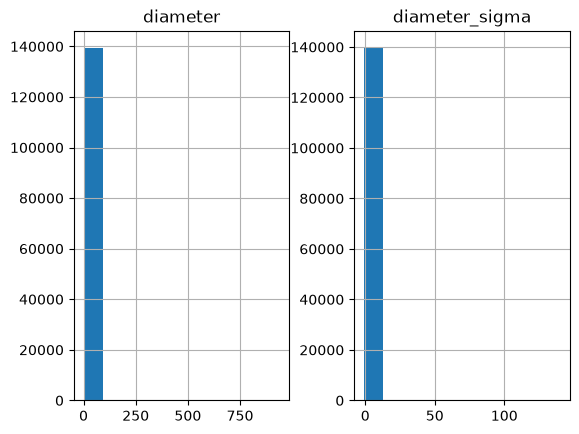

In [355]:
df.hist()

array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>]], dtype=object)

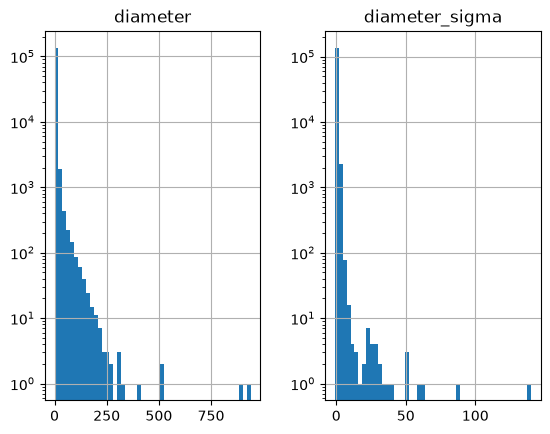

In [356]:
# Strong outliers demand a log scale for better visualization
df.hist(log=True, bins=50)

<Axes: >

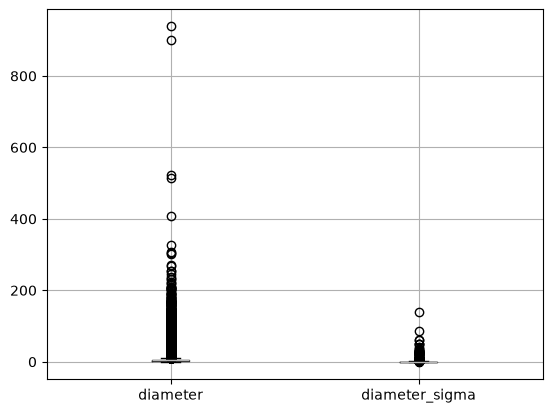

In [357]:
# Boxplots to check outliers
df.boxplot()

In [358]:
# Check relative uncertainty
df['relative_sigma'] = df['diameter_sigma'] / df['diameter']

array([[<Axes: title={'center': 'diameter'}>,
        <Axes: title={'center': 'diameter_sigma'}>],
       [<Axes: title={'center': 'relative_sigma'}>, <Axes: >]],
      dtype=object)

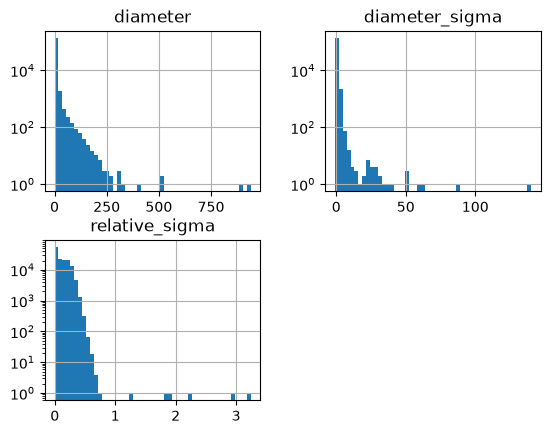

In [359]:
df.hist(log=True, bins=50)

In [360]:
# Extend the description
def super_description(df):
  uni = df.describe().drop('count')

  kurts = df.select_dtypes(
    include="number"
  ).kurtosis().to_frame().T.rename(
    index={0: "kurt"}
  )
  uni = pd.concat([uni, kurts])

  iqr = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
  ).to_frame().T.rename(
    index={0: "iqr"}
  )
  uni = pd.concat([uni, iqr])

  outliers = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: (x < x.quantile(0.25) - 1.5 * x.quantile(0.75)) |
              (x > x.quantile(0.75) + 1.5 * x.quantile(0.25))
  ).sum().to_frame().T.rename(
    index={0: "outs"}
  )
  uni = pd.concat([uni, outliers])

  outliers_perc = df.select_dtypes(
    include="number"
  ).apply(
    lambda x: (x < x.quantile(0.25) - 1.5 * x.quantile(0.75)) |
              (x > x.quantile(0.75) + 1.5 * x.quantile(0.25))
  ).mean().to_frame().T.rename(
    index={0: "outs (%)"}
  ) * 100
  uni = pd.concat([uni, outliers_perc])

  display(uni)

super_description(df)

,diameter,diameter_sigma,relative_sigma
mean,5.441043,0.486065,0.127632
std,9.142136,0.798903,0.105188
min,0.002500,-1.000000,-0.004505
25%,2.765000,0.180000,0.035336
50%,3.951000,0.340000,0.098557
75%,5.732000,0.630000,0.206973
max,939.400000,140.000000,3.238843
kurt,1769.648966,8721.215751,11.264301
iqr,2.967000,0.450000,0.171637
outs,10408.000000,17917.000000,17925.000000


In [361]:
# Check negative sigmas
df.loc[
    df["diameter_sigma"] < 0,
    ["pdes", "full_name", "diameter", "diameter_sigma"]
]

,pdes,full_name,diameter,diameter_sigma
15,16,16 Psyche (A852 FA),222.0,-1.0


In [362]:
# Delete it as it is only one
df = df[df["diameter_sigma"] >= 0].copy()

In [363]:
super_description(df)

,diameter,diameter_sigma,relative_sigma
mean,5.439491,0.486075,0.127633
std,9.123760,0.798896,0.105188
min,0.002500,0.000000,0.000000
25%,2.765000,0.180000,0.035336
50%,3.951000,0.340000,0.098558
75%,5.731500,0.630000,0.206974
max,939.400000,140.000000,3.238843
kurt,1781.728653,8721.582464,11.264461
iqr,2.966500,0.450000,0.171638
outs,10407.000000,17916.000000,17925.000000


In [364]:
# Objects per threshold

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50, 1.00]

for threshold in thresholds:
    n = (df["relative_sigma"] <= threshold).sum()
    percentage = 100 * n / len(df)

    print(
        f"{threshold:.0%}: "
        f"{n:,} objects ({percentage:.2f}%)"
    )

5%: 48,132 objects (34.51%)
10%: 70,149 objects (50.30%)
15%: 84,678 objects (60.71%)
20%: 102,150 objects (73.24%)
25%: 118,710 objects (85.11%)
30%: 130,146 objects (93.31%)
50%: 139,339 objects (99.91%)
100%: 139,465 objects (100.00%)


In [365]:
# Quantiles per threshold

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50]

for threshold in thresholds:

    filtered = df[
        df["relative_sigma"] <= threshold
    ]

    q25 = filtered["diameter"].quantile(0.25)
    q50 = filtered["diameter"].quantile(0.50)
    q75 = filtered["diameter"].quantile(0.75)

    print(
        f"{threshold:>5.0%} | "
        f"N = {len(filtered):>7,} | "
        f"Q25 = {q25:.3f} | "
        f"Median = {q50:.3f} | "
        f"Q75 = {q75:.3f}"
    )

   5% | N =  48,132 | Q25 = 4.391 | Median = 5.931 | Q75 = 8.333
  10% | N =  70,149 | Q25 = 3.957 | Median = 5.323 | Q75 = 7.401
  15% | N =  84,678 | Q25 = 3.489 | Median = 4.924 | Q75 = 6.943
  20% | N = 102,150 | Q25 = 3.067 | Median = 4.473 | Q75 = 6.435
  25% | N = 118,710 | Q25 = 2.858 | Median = 4.161 | Q75 = 6.062
  30% | N = 130,146 | Q25 = 2.788 | Median = 4.021 | Q75 = 5.867
  50% | N = 139,339 | Q25 = 2.765 | Median = 3.950 | Q75 = 5.732


In [366]:
# Stronger search

thresholds = [0.25, 0.27, 0.28, 0.30, 0.32, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:

    filtered = df[
        df["relative_sigma"] <= threshold
    ]

    q25 = filtered["diameter"].quantile(0.25)
    q50 = filtered["diameter"].quantile(0.50)
    q75 = filtered["diameter"].quantile(0.75)

    print(
        f"{threshold:>5.0%} | "
        f"N = {len(filtered):>7,} | "
        f"Q25 = {q25:.3f} | "
        f"Median = {q50:.3f} | "
        f"Q75 = {q75:.3f}"
    )

  25% | N = 118,710 | Q25 = 2.858 | Median = 4.161 | Q75 = 6.062
  27% | N = 124,135 | Q25 = 2.819 | Median = 4.089 | Q75 = 5.967
  28% | N = 126,410 | Q25 = 2.807 | Median = 4.060 | Q75 = 5.931
  30% | N = 130,146 | Q25 = 2.788 | Median = 4.021 | Q75 = 5.867
  32% | N = 133,036 | Q25 = 2.777 | Median = 3.993 | Q75 = 5.821
  35% | N = 135,879 | Q25 = 2.769 | Median = 3.969 | Q75 = 5.777
  40% | N = 138,203 | Q25 = 2.764 | Median = 3.954 | Q75 = 5.745
  45% | N = 139,053 | Q25 = 2.765 | Median = 3.951 | Q75 = 5.734
  50% | N = 139,339 | Q25 = 2.765 | Median = 3.950 | Q75 = 5.732


In [367]:
# Considering the previous results, around 30 % seems acceptable as it represents the place where quantiles start changing less. Additionally, it still keeps a good portion of asteroids.

# We filter the data to only keep those objects with a relative uncertainty of 30 % or less
df = df[df['relative_sigma'] <= 0.30]

In [368]:
df.describe()

,diameter,diameter_sigma,relative_sigma
count,130146.000000,130146.000000,130146.000000
mean,5.566397,0.427276,0.111566
std,9.383536,0.682161,0.087458
min,0.002500,0.000000,0.000000
25%,2.788250,0.170000,0.033012
50%,4.021000,0.320000,0.082890
75%,5.867000,0.560000,0.187266
max,939.400000,140.000000,0.300000


In [369]:
# Read local MPCORB database
mpc = pd.read_csv(r"../data/body_classification.csv")

In [391]:
mpc.head()

,designation,is_numbered,is_provisional,orbit_uncertainty,is_eccentricity_assumed,has_multiple_designation,is_neo,is_mca,is_mba,is_tjn,is_cen,is_tno,is_paa,is_hya,is_ast
0,Ceres,True,False,0.0,False,False,False,False,True,False,False,False,False,False,False
1,Pallas,True,False,0.0,False,False,False,False,True,False,False,False,False,False,False
2,Juno,True,False,0.0,False,False,False,False,True,False,False,False,False,False,False
3,Vesta,True,False,0.0,False,False,False,False,True,False,False,False,False,False,False
4,Astraea,True,False,0.0,False,False,False,False,True,False,False,False,False,False,False


In [ ]:
# Check full names
for name in df['full_name']:
  print(name)

     1 Ceres (A801 AA)
     2 Pallas (A802 FA)
     3 Juno (A804 RA)
     4 Vesta (A807 FA)
     5 Astraea (A845 XA)
     6 Hebe (A847 NA)
     7 Iris (A847 PA)
     8 Flora (A847 UA)
    10 Hygiea (A849 GA)
    11 Parthenope (A850 JA)
    12 Victoria (A850 RA)
    13 Egeria (A850 VA)
    15 Eunomia (A851 OA)
    17 Thetis (A852 HA)
    18 Melpomene (A852 MA)
    20 Massalia (A852 SA)
    21 Lutetia (A852 VA)
    22 Kalliope (A852 WA)
    23 Thalia (A852 XA)
    25 Phocaea (A853 GB)
    26 Proserpina (A853 JA)
    28 Bellona (A854 EA)
    29 Amphitrite (A854 EB)
    30 Urania (A854 OA)
    31 Euphrosyne (A854 RA)
    32 Pomona (A854 UA)
    33 Polyhymnia (A854 UB)
    34 Circe (A855 GA)
    35 Leukothea (A855 HA)
    36 Atalante (A855 TA)
    37 Fides (A855 TB)
    38 Leda (A856 AA)
    39 Laetitia (A856 CA)
    40 Harmonia (A856 FA)
    41 Daphne (A856 KA)
    42 Isis (A856 KB)
    43 Ariadne (A857 GA)
    44 Nysa (A857 KA)
    45 Eugenia (A857 MA)
    46 Hestia (A857 QA)
    47 Aglaj

In [424]:
# Copy
sbdb = df.copy()

In [425]:
# Use regular expressions to adjust the full name column to the same format as that of local MPCORB classification database
sbdb['full_name'] = sbdb['full_name'].str.replace(r'^\s+', '', regex=True)
sbdb['full_name'] = sbdb['full_name'].str.replace(r'^\d+\s', '', regex=True)
sbdb['full_name'] = sbdb['full_name'].str.replace(r'(\w)(\s\(.+\))', r'\1', regex=True)
sbdb['full_name'] = sbdb['full_name'].str.replace(r'(\()([^\(\)]+)(\))', r'\2', regex=True)

In [426]:
# Keep only those objects available in MPC
sbdb['is_contained'] = sbdb['full_name'].isin(mpc['designation'])
sbdb = sbdb[sbdb['is_contained'] == True].drop(columns='is_contained')

# Create new column for families
sbdb['family'] = pd.Series(pd.NA, index=sbdb.index, dtype='string')

In [427]:
import re


# Function to test if it is the current type
def is_type(name, type, mpc):
    return mpc.loc[mpc['designation'] == name, type].iloc[0]


# Types and classes from each type
types = [
    'is_neo',
    'is_mca',
    'is_mba',
    'is_tjn',
    'is_cen',
    'is_tno',
    'is_paa',
    'is_hya',
    'is_ast'
]

classes = [re.sub(r'is_', '', x) for x in types]

for t, c in zip(types, classes):

    mask_mpc = mpc[t]

    designations = set(mpc.loc[mask_mpc, 'designation'])

    mask_sbdb = (
        sbdb['full_name'].isin(designations)
        & sbdb['family'].isna()
    )

    sbdb.loc[mask_sbdb, 'family'] = c

In [429]:
sbdb['family'].value_counts()

family
mba    125980
tjn      1874
neo       900
mca       576
ast       486
cen        50
tno        11
Name: count, dtype: Int64

In [ ]:
# Separate objects based on families
mbas = sbdb[sbdb['family'] == 'mba']
tjns = sbdb[sbdb['family'] == 'tjn']
neos = sbdb[sbdb['family'] == 'neo']
mcas = sbdb[sbdb['family'] == 'mca']
asts = sbdb[sbdb['family'] == 'ast']
cens = sbdb[sbdb['family'] == 'cen']
tnos = sbdb[sbdb['family'] == 'tno']

In [ ]:
# Print out ranges of diameters
print(f'MBA:\t{mbas['diameter'].quantile(0.25):.3f}\t-\t{mbas['diameter'].quantile(0.75):.3f}')
print(f'TJN:\t{tjns['diameter'].quantile(0.25):.3f}\t-\t{tjns['diameter'].quantile(0.75):.3f}')
print(f'NEO:\t{neos['diameter'].quantile(0.25):.3f}\t-\t{neos['diameter'].quantile(0.75):.3f}')
print(f'MCA:\t{mcas['diameter'].quantile(0.25):.3f}\t-\t{mcas['diameter'].quantile(0.75):.3f}')
print(f'AST:\t{asts['diameter'].quantile(0.25):.3f}\t-\t{asts['diameter'].quantile(0.75):.3f}')
print(f'CEN:\t{cens['diameter'].quantile(0.25):.3f}\t-\t{cens['diameter'].quantile(0.75):.3f}')
print(f'TNO:\t{tnos['diameter'].quantile(0.25):.3f}\t-\t{tnos['diameter'].quantile(0.75):.3f}')

MBA:	2.809	-	5.778
TJN:	12.424	-	21.920
NEO:	0.282	-	1.188
MCA:	1.734	-	3.400
AST:	1.439	-	2.935
CEN:	4.280	-	57.750
TNO:	15.250	-	181.000
